# Part 1: EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

## 1. DataSet overview

In [2]:
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. Data quality

In [6]:
for column in df.columns:
    print(column)
    print(f"N/A quantity {df[column].isna().sum()} ({((df[column].isna().sum() / df[column].shape[0]) * 100):.2f}%)")
    print(f"Quantity of unique values: {df[column].nunique()}")
    print()

step
N/A quantity 0 (0.00%)
Quantity of unique values: 743

type
N/A quantity 0 (0.00%)
Quantity of unique values: 5

amount
N/A quantity 0 (0.00%)
Quantity of unique values: 5316900

nameOrig
N/A quantity 0 (0.00%)
Quantity of unique values: 6353307

oldbalanceOrg
N/A quantity 0 (0.00%)
Quantity of unique values: 1845844

newbalanceOrig
N/A quantity 0 (0.00%)
Quantity of unique values: 2682586

nameDest
N/A quantity 0 (0.00%)
Quantity of unique values: 2722362

oldbalanceDest
N/A quantity 0 (0.00%)
Quantity of unique values: 3614697

newbalanceDest
N/A quantity 0 (0.00%)
Quantity of unique values: 3555499

isFraud
N/A quantity 0 (0.00%)
Quantity of unique values: 2

isFlaggedFraud
N/A quantity 0 (0.00%)
Quantity of unique values: 2



In [7]:
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 0


In [8]:
for col in ['type', 'isFraud', 'isFlaggedFraud']:
    print(f"{col}: {df[col].unique()}")

type: <StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str
isFraud: [0 1]
isFlaggedFraud: [0 1]


## 3. Target analysis

In [9]:
df['isFraud'].value_counts().sort_index()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

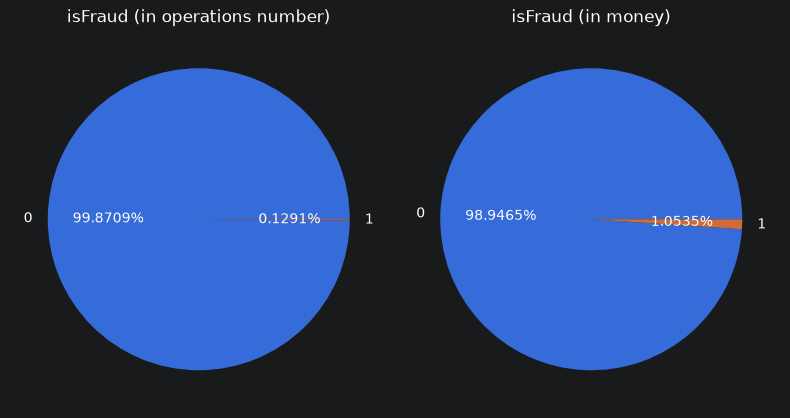

In [10]:
_is_fraud = df['isFraud'].value_counts()
money_is_fraud = df.groupby('isFraud')['amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(8, 8))
(ax1, ax2) = axes.flatten()

ax1.pie(_is_fraud,
        labels=_is_fraud.index,
        radius=1,
        autopct='%.4f%%',
        textprops=dict(color='white', fontsize=10)
)
ax1.set_title('isFraud (in operations number)')

ax2.pie(money_is_fraud,
        labels=money_is_fraud.index,
        radius=1,
        autopct='%.4f%%',
        textprops=dict(color='white', fontsize=10)
)
ax2.set_title('isFraud (in money)')

plt.tight_layout()
plt.show()

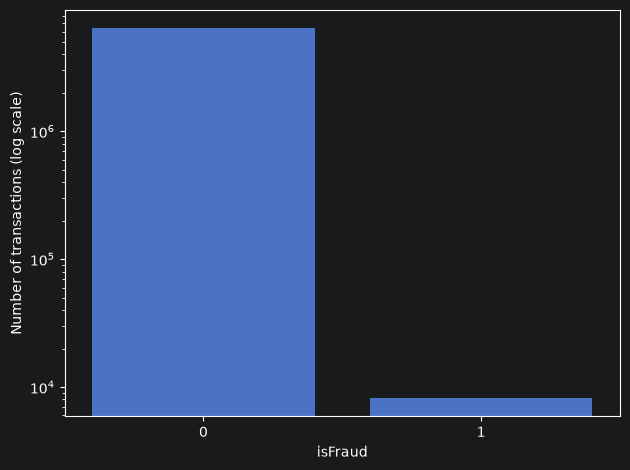

In [11]:
fraud_counts = df['isFraud'].value_counts().sort_index()

ax = sns.barplot(
    x=fraud_counts.index.astype(str),
    y=fraud_counts.values
)

ax.set_yscale('log')
ax.set_xlabel('isFraud')
ax.set_ylabel('Number of transactions (log scale)')
plt.tight_layout()
plt.show()

In [12]:
bin_size = 5

fraud_by_step = (
    df.groupby('step')
      .agg(
          transactions=('isFraud', 'size'),
          fraud_count=('isFraud', 'sum'),
          fraud_rate=('isFraud', 'mean')
      )
).reset_index()

fraud_by_step["step_group"] = fraud_by_step["step"] // bin_size


agg = (
    fraud_by_step
    .groupby("step_group", as_index=False)
    .agg(
        transactions=("transactions", "sum"),
        fraud_count=("fraud_count", "sum")
    )
)

agg["fraud_rate"] = (
    agg["fraud_count"] / agg["transactions"]
)

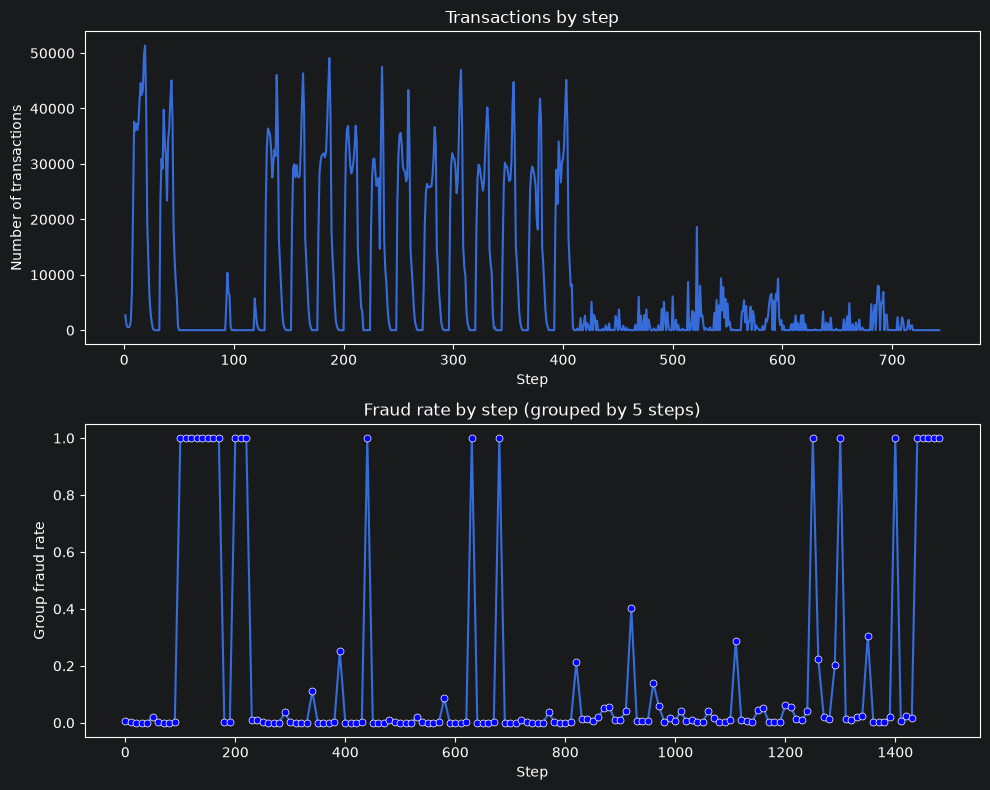

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
(ax1, ax2) = axes.flatten()

sns.lineplot(
    data=fraud_by_step,
    x='step',
    y='transactions',
    ax=ax1
)

ax1.set_title('Transactions by step')
ax1.set_xlabel('Step')
ax1.set_ylabel('Number of transactions')


sns.lineplot(
    data=agg,
    x='step_group',
    y='fraud_rate',
    ax=ax2,
    marker="o",
    markersize=5,
    markerfacecolor='blue',
    markeredgewidth=0.5
)

ax2.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x * 10:.0f}')
)
ax2.set_title('Fraud rate by step (grouped by 5 steps)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Group fraud rate')


plt.tight_layout()
plt.show()

The target variable is extremely imbalanced: only 8,213 out of 6,362,620 transactions are fraudulent (~0.129%).

Consequently, accuracy will not be an informative evaluation metric. A classifier predicting every transaction as legitimate would already achieve approximately 99.87% accuracy.

Model evaluation should therefore focus primarily on metrics designed for imbalanced classification, such as PR-AUC, precision, recall and F1-score. The final decision threshold should also be evaluated from a business perspective by considering the relative costs of false positives and false negatives.

## 4. Transaction types

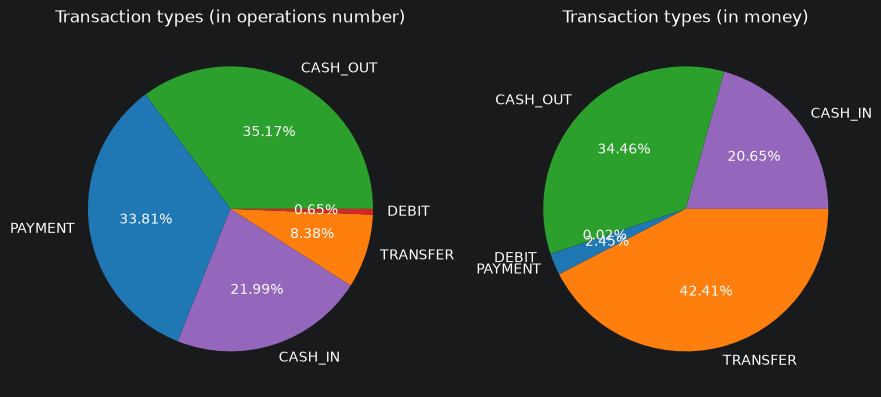

In [14]:
_type = df['type'].value_counts()
money_type = df.groupby('type')['amount'].sum()

# color setiings
types = df['type'].unique()
colors = plt.cm.tab10.colors

color_map = {
    transaction_type: colors[i]
    for i , transaction_type in enumerate(types)
}


fig, axes = plt.subplots(1, 2, figsize=(9, 9))
(ax1, ax2) = axes.flatten()

ax1.pie(_type,
        labels=_type.index,
        radius=1,
        colors=[color_map[x] for x in _type.index],
        autopct='%.2f%%',
        textprops=dict(color='white', fontsize=10),
)
ax1.set_title('Transaction types (in operations number)')

ax2.pie(money_type,
        labels=money_type.index,
        radius=1,
        colors=[color_map[x] for x in money_type.index],
        autopct='%.2f%%',
        textprops=dict(color='white', fontsize=10)
)
ax2.set_title('Transaction types (in money)')

plt.tight_layout()
plt.show()

## 5. Fraud transaction by type

In [15]:
(df.groupby('type')
  .agg(
      transactions=('isFraud', 'size'),
      fraud_count=('isFraud', 'sum'),
      fraud_rate=('isFraud', 'mean')
  )
  .sort_values('fraud_rate', ascending=False))

,transactions,fraud_count,fraud_rate
type,,,
TRANSFER,532909,4097,0.007688
CASH_OUT,2237500,4116,0.001840
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [16]:
temp_df = df.copy()

fraud_dict = {
    0 : 'honest',
    1 : 'fraud'
}
temp_df['isFraud'] = temp_df['isFraud'].map(fraud_dict)

In [17]:
outer_money = temp_df.groupby(['type'])['amount'].sum()

inner_money = temp_df.groupby(['type', 'isFraud'])['amount'].sum()
inner_money_labels= inner_money.index.get_level_values(1)

In [18]:
outer_tranc = temp_df.groupby(['type'])['amount'].count()

inner_tranc = temp_df.groupby(['type', 'isFraud'])['amount'].count()
inner_tranc_labels= inner_tranc.index.get_level_values(1)

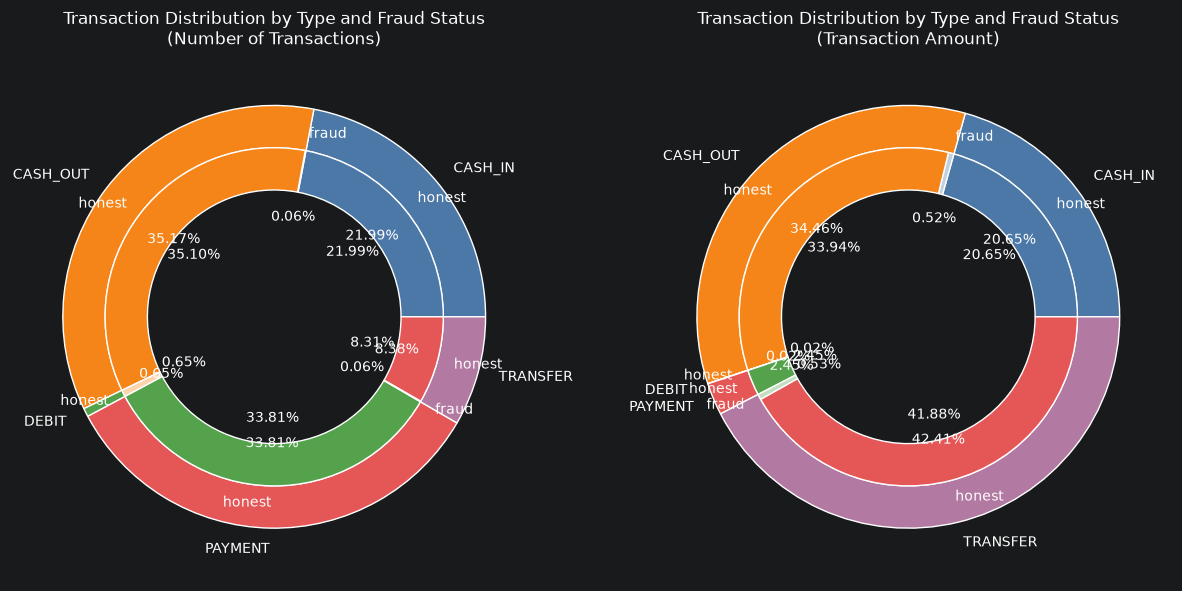

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 12))
(ax1, ax2) = axes.flatten()
radius = 1.0
size = 0.2

outer_colors = [
    '#4C78A8',  # CASH_IN
    '#F58518',  # CASH_OUT
    '#54A24B',  # DEBIT
    '#E45756',  # PAYMENT
    '#B279A2',  # TRANSFER
]

def lighten_color(color, amount=0.45):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)


inner_colors = []

for color in outer_colors:
    inner_colors.extend([
        color,
        lighten_color(color, 0.65)
    ])

ax1.pie(outer_tranc.values.flatten(),
       radius=radius, labels=outer_tranc.index, autopct='%.2f%%',
       colors=outer_colors, wedgeprops=dict(width=size, edgecolor='w'))

ax1.pie(inner_tranc.values.flatten(),
       radius=radius - size, labels=inner_tranc_labels, autopct='%.2f%%',
       colors=inner_colors, wedgeprops=dict(width=size, edgecolor='w'))

ax1.set_title(
    'Transaction Distribution by Type and Fraud Status\n'
    '(Number of Transactions)'
)


ax2.pie(outer_money.values.flatten(),
       radius=radius, labels=outer_money.index, autopct='%.2f%%',
       colors=outer_colors, wedgeprops=dict(width=size, edgecolor='w'))

ax2.pie(inner_money.values.flatten(),
       radius=radius - size, labels=inner_money_labels, autopct='%.2f%%',
       colors=inner_colors, wedgeprops=dict(width=size, edgecolor='w'))

ax2.set_title(
    'Transaction Distribution by Type and Fraud Status\n'
    '(Transaction Amount)'
)

plt.show()

Fraud is not distributed uniformly across transaction types. Transaction type is therefore likely to be an important predictive feature.

## 6. Transaction amount analysis

In [20]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [21]:
bin_size = 10

temp_df = df.copy()

temp_df['step_group'] = temp_df['step'] // bin_size

agg = (
    temp_df.groupby(['step_group', 'isFraud'], as_index=False)
      .agg(
          total_amount=('amount', 'sum'),
          amount_mean=('amount', 'mean'),
          amount_median=('amount', 'median')
      )
)

agg['amount_share'] = (
    agg['total_amount']
    / agg.groupby('step_group')['total_amount'].transform('sum')
)

plot_data = agg.pivot(
    index='step_group',
    columns='isFraud',
    values='amount_share'
)

fraud_share = plot_data[1]

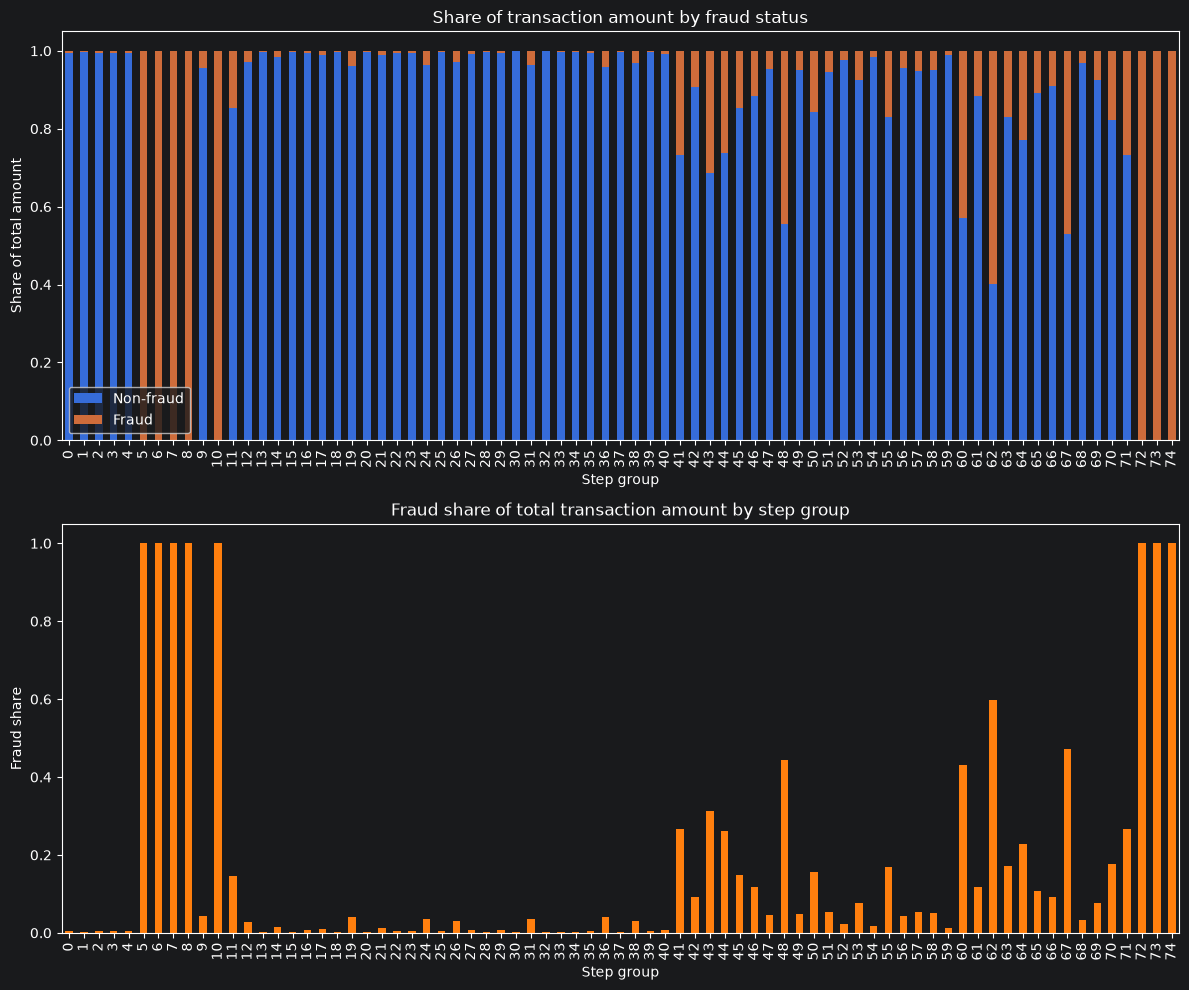

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
(ax1, ax2) = axes.flatten()

plot_data.plot(
    kind='bar',
    stacked=True,
    linewidth=1,
    ax=ax1
)
ax1.set_title('Share of transaction amount by fraud status')
ax1.set_xlabel('Step group')
ax1.set_ylabel('Share of total amount')
ax1.legend(['Non-fraud', 'Fraud'])


fraud_share.plot(
    kind='bar',
    linewidth=1,
    ax=ax2,
    color='tab:orange'
)
ax2.set_xlabel('Step group')
ax2.set_ylabel('Fraud share')
ax2.set_title('Fraud share of total transaction amount by step group')


plt.tight_layout()
plt.show()

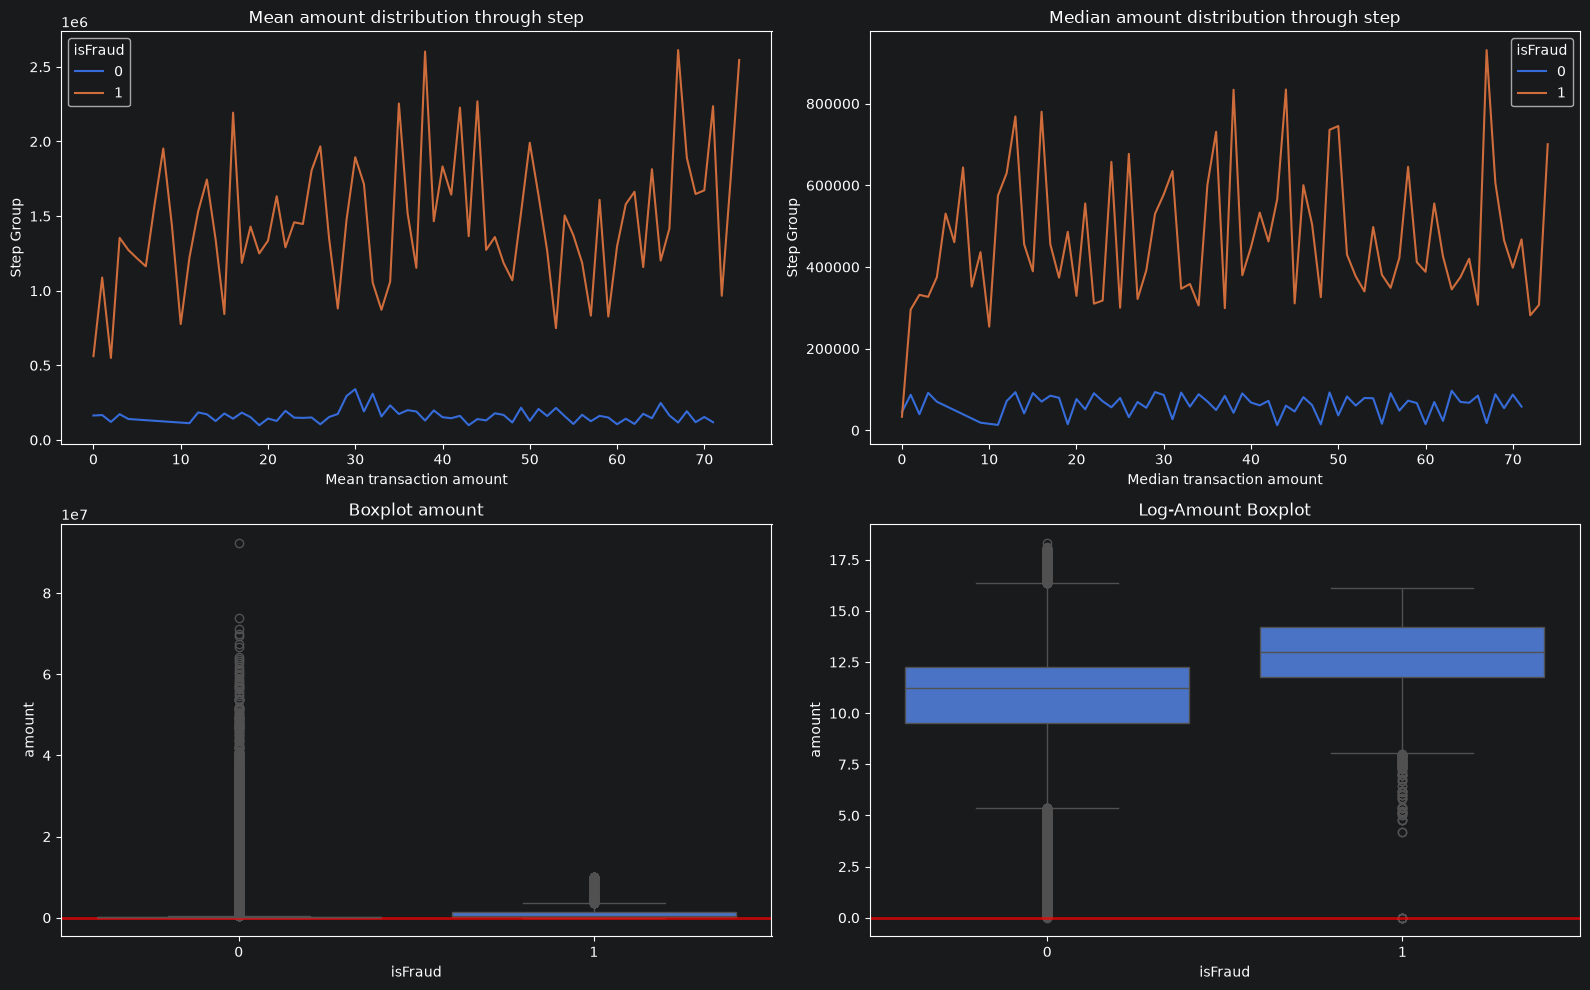

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
(ax1, ax2, ax3, ax4) = axes.flatten()

sns.lineplot(data=agg, x='step_group', y='amount_mean', hue='isFraud', ax=ax1)
ax1.set_title('Mean amount distribution through step')
ax1.set_xlabel('Mean transaction amount')
ax1.set_ylabel('Step Group')


sns.lineplot(data=agg, x='step_group', y='amount_median', hue='isFraud', ax=ax2)
ax2.set_title('Median amount distribution through step')
ax2.set_xlabel('Median transaction amount')
ax2.set_ylabel('Step Group')


sns.boxplot(data=df, x='isFraud', y='amount', ax=ax3)
ax3.set_title('Boxplot amount')
ax3.axhline(y=0, color='red', linestyle='-', linewidth=2, alpha=0.7)

sns.boxplot(data=df, x='isFraud', y=np.log1p(df['amount']), ax=ax4)
ax4.set_title('Log-Amount Boxplot')
ax4.axhline(y=0, color='red', linestyle='-', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.show()

Fraudulent transactions tend to have substantially larger transaction amounts than legitimate transactions. The amount distribution is strongly right-skewed, therefore a log-transformed version of amount (log1p(amount)) will be considered for models sensitive to feature scale and distribution.

## 7. Account balance analysis

In [24]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [25]:
df['orig_balance_error'] = (
    df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
)

df['dest_balance_error'] = (
    df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
)

In [26]:
temp = df.groupby('isFraud').agg(
    orig_balance_error_mean=('orig_balance_error', 'mean'),
    orig_balance_error_median=('orig_balance_error', 'median'),
    dest_balance_error_mean=('dest_balance_error', 'mean'),
    dest_balance_error_median=('dest_balance_error', 'median')
)

temp

,orig_balance_error_mean,orig_balance_error_median,dest_balance_error_mean,dest_balance_error_median
isFraud,,,,
0,-201338.558109,-69049.31,54692.231734,3500.68
1,-10692.325265,0.00,732509.301069,2231.46


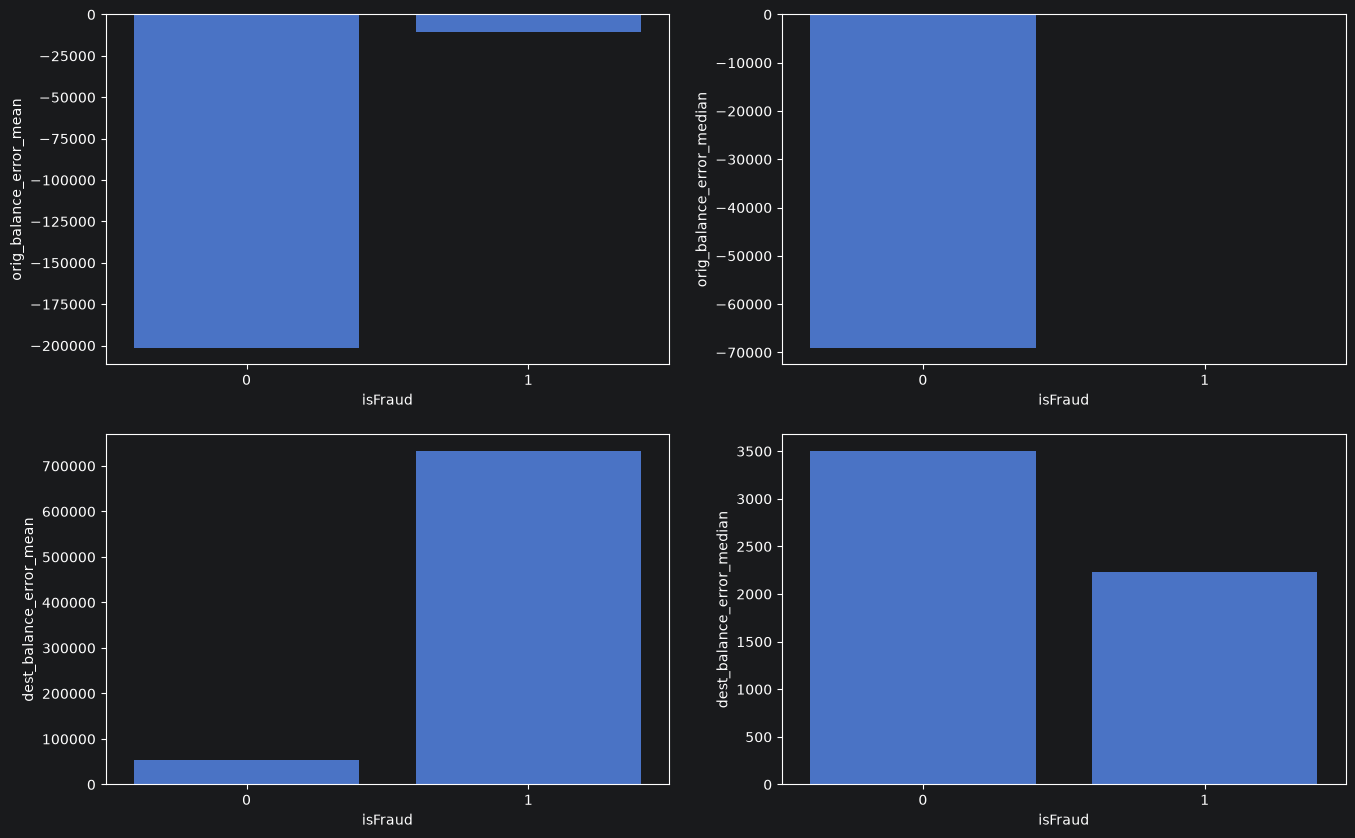

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
(ax1, ax2, ax3, ax4) = axes.flatten()

sns.barplot(
    data=temp,
    x=temp.index,
    y='orig_balance_error_mean',
    ax=ax1
)

sns.barplot(
    data=temp,
    x=temp.index,
    y='orig_balance_error_median',
    ax=ax2
)

sns.barplot(
    data=temp,
    x=temp.index,
    y='dest_balance_error_mean',
    ax=ax3
)

sns.barplot(
    data=temp,
    x=temp.index,
    y='dest_balance_error_median',
    ax=ax4
)

plt.show()

In [28]:
temp = df[(df['oldbalanceOrg']==0) & (df['newbalanceOrig']==0)]

print(f"Lenght: {temp.shape[0]}")
print(f'Fraud cosistent: {len(temp[temp['isFraud']==1])}')
print(f" Fraud rate: {round(len(temp[temp['isFraud']==1]) / temp.shape[0]*100, 5)}%")

Lenght: 2088985
Fraud cosistent: 41
 Fraud rate: 0.00196%


In [29]:
temp = df[(df['oldbalanceDest']==0) & (df['newbalanceDest']==0)]

print(f"Lenght: {temp.shape[0]}")
print(f'Fraud cosistent: {len(temp[temp['isFraud']==1])}')
print(f" Fraud rate: {round(len(temp[temp['isFraud']==1]) / temp.shape[0]*100, 5)}%")

Lenght: 2317282
Fraud cosistent: 4076
 Fraud rate: 0.1759%


In [30]:
temp = df[(df['oldbalanceOrg']==0) & (df['newbalanceOrig']==0) & (df['oldbalanceDest']==0) & (df['newbalanceDest']==0)]

print(f"Lenght: {temp.shape[0]}")
print(f'Fraud cosistent: {len(temp[temp['isFraud']==1])}')
print(f" Fraud rate: {round(len(temp[temp['isFraud']==1]) / temp.shape[0]*100, 5)}%")

Lenght: 774275
Fraud cosistent: 6
 Fraud rate: 0.00077%


In [31]:
temp = df[(df['oldbalanceOrg']==0) & (df['oldbalanceDest']==0)]

print(f"Lenght: {temp.shape[0]}")
print(f'Fraud cosistent: {len(temp[temp['isFraud']==1])}')
print(f" Fraud rate: {round(len(temp[temp['isFraud']==1]) / temp.shape[0]*100, 5)}%")

Lenght: 776105
Fraud cosistent: 16
 Fraud rate: 0.00206%


In [32]:
temp = df[(df['newbalanceOrig']==0) & (df['newbalanceDest']==0)]

print(f"Lenght: {temp.shape[0]}")
print(f'Fraud cosistent: {len(temp[temp['isFraud']==1])}')
print(f" Fraud rate: {round(len(temp[temp['isFraud']==1]) / temp.shape[0]*100, 5)}%")

Lenght: 1115358
Fraud cosistent: 3933
 Fraud rate: 0.35262%


**Potential data leakage**

Balance-related features show substantial differences between fraudulent and legitimate transactions. However, according to the dataset description *"Transactions identified as fraudulent are annulled. Hence, for fraud detection analysis, the following columns should not be utilized: oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest"*

Therefore, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest, as well as features derived from them such as orig_balance_error and dest_balance_error, may contain information that would not be available at transaction scoring time.

To avoid overly optimistic model performance, balance-based features will be excluded from the primary fraud detection model.

## 9. Existing fraud flag analisys

In [33]:
pd.crosstab(
    df['isFlaggedFraud'],
    df['isFraud'],
    margins=True
)

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


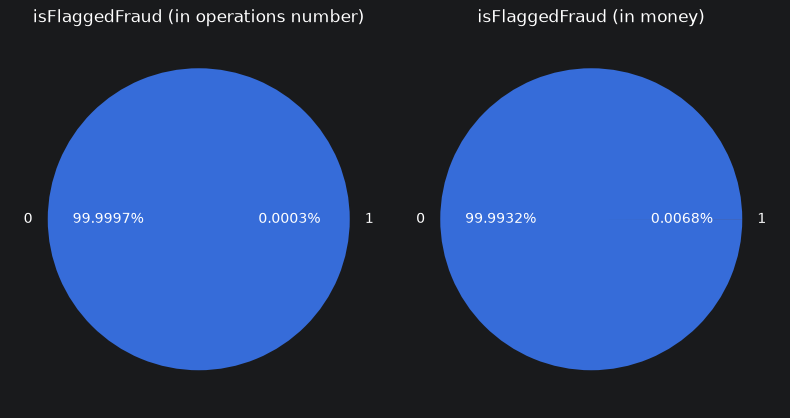

In [34]:
_is_flagged_fraud = df['isFlaggedFraud'].value_counts()
money_is_flagged_fraud = df.groupby('isFlaggedFraud')['amount'].sum()


fig, axes = plt.subplots(1, 2, figsize=(8, 8))
(ax1, ax2) = axes.flatten()


ax1.pie(_is_flagged_fraud,
        labels=_is_flagged_fraud.index,
        radius=1,
        autopct='%.4f%%',
        textprops=dict(color='white', fontsize=10)
)
ax1.set_title('isFlaggedFraud (in operations number)')

ax2.pie(money_is_flagged_fraud,
        labels=money_is_flagged_fraud.index,
        radius=1,
        autopct='%.4f%%',
        textprops=dict(color='white', fontsize=10)
)
ax2.set_title('isFlaggedFraud (in money)')

plt.tight_layout()
plt.show()

In [35]:
tp = df[(df['isFraud']==1) & (df['isFlaggedFraud']==1)].shape[0]
fp = df[(df['isFraud']==0) & (df['isFlaggedFraud']==1)].shape[0]
tn = df[(df['isFraud']==0) & (df['isFlaggedFraud']==0)].shape[0]
fn = df[(df['isFraud']==1) & (df['isFlaggedFraud']==0)].shape[0]

print(f"True positive: {tp}")
print(f"False positive: {fp}")
print(f"True negative: {tn}")
print(f"False negative: {fn}")

True positive: 16
False positive: 0
True negative: 6354407
False negative: 8197


Existing fraud rule

isFlaggedFraud has extremely high precision but extremely low recall. All 16 flagged transactions are fraudulent, but the rule detects only 16 out of 8,213 fraudulent transactions.

Therefore, the existing rule is very conservative and cannot serve as a complete fraud detection system.

## 10. Correcaltion Analysis

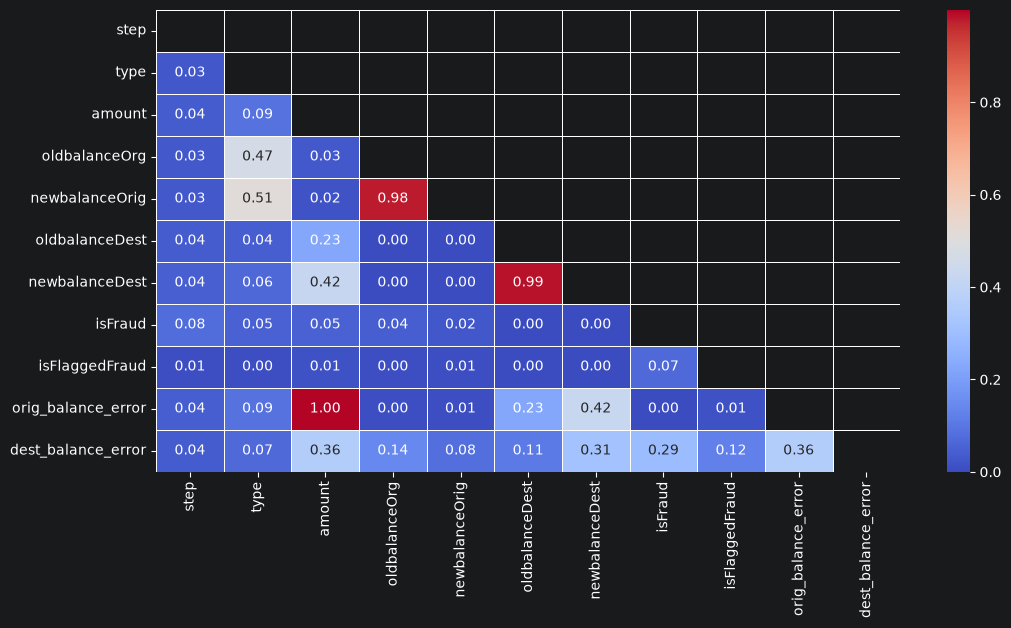

In [36]:
interval_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                 'oldbalanceDest', 'newbalanceDest', 'isFraud',
                 'isFlaggedFraud', 'dest_balance_error', 'orig_balance_error']
corr_data = df.drop(['nameDest', 'nameOrig'], axis=1).phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask)
plt.show()

## Conclusions

The exploratory analysis revealed several important properties of the dataset:

  * The target is extremely imbalanced (~0.129% fraud), making accuracy unsuitable as the primary evaluation metric.
  * Fraud occurrence varies substantially across transaction types, suggesting that type is an important predictive feature.
  * Fraudulent transactions tend to involve larger amounts, and the amount distribution is strongly right-skewed.
  * Transaction time may provide useful predictive information and can be decomposed into hour/day features.
  * Balance-related variables show strong associations with fraud, but they may introduce target leakage and will therefore be excluded from the primary model.
  * isFlaggedFraud represents an existing rule-based fraud detector with very high precision but extremely low recall
  * Raw account identifiers have very high cardinality and will not be directly encoded in the baseline model.

Based on these findings, the next stage will build a leakage-safe baseline model and evaluate it using metrics appropriate for highly imbalanced classification, primarily PR-AUC, precision and recall.